Predictions notebook 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix


In [2]:
big_nss = pd.read_csv("../data/big_nss_clean.csv")

feature_cols = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd', 'EngineOilPressure', 'EngineOilTemperature']
target_col = 'Derate'

X = big_nss[feature_cols]
y = big_nss[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")
print(f"Derate rate — train: {y_train.mean():.4f}  |  test: {y_test.mean():.4f}")

C:\Users\blond\AppData\Local\Temp\ipykernel_60948\356195352.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  big_nss = pd.read_csv("../data/big_nss_clean.csv")


Training rows: 470,104  |  Test rows: 117,526
Derate rate — train: 0.0010  |  test: 0.0009


i asked for explanation for the derate rate and it stated that .1% of rows are derate in the training, so it will likely report a high rate of accuracy by just predicting not derate each time.... 


In [3]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

odds_ratios = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Odds Ratio', ascending=False)
print("\nOdds Ratios:")
print(odds_ratios.to_string(index=False))

=== Logistic Regression ===
Accuracy: 0.9990

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    117423
        True       0.00      0.00      0.00       103

    accuracy                           1.00    117526
   macro avg       0.50      0.50      0.50    117526
weighted avg       1.00      1.00      1.00    117526


Odds Ratios:
             Feature  Coefficient  Odds Ratio
             FuelLtd     0.000011    1.000011
         DistanceLtd    -0.000004    0.999996
       EngineTimeLtd    -0.000066    0.999934
EngineOilTemperature    -0.030627    0.969837
   EngineOilPressure    -0.055340    0.946164


In [4]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importances:")
print(importance.to_string(index=False))

=== Random Forest ===
Accuracy: 0.9989

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    117423
        True       0.11      0.04      0.06       103

    accuracy                           1.00    117526
   macro avg       0.56      0.52      0.53    117526
weighted avg       1.00      1.00      1.00    117526


Feature Importances:
             Feature  Importance
EngineOilTemperature    0.258737
   EngineOilPressure    0.245854
       EngineTimeLtd    0.169860
             FuelLtd    0.166486
         DistanceLtd    0.159063


notes on types:   

Logistic Regression draws a straight-line boundary between classes and outputs a probability based on which side a point falls on; the odds ratio tells you exactly how much each feature shifts the prediction, but it can miss complex patterns.

Random Forest builds hundreds of decision trees on random data subsets and takes a majority vote, capturing non-linear relationships (e.g., "high oil pressure is fine unless engine time is also very high") at the cost of interpretability — feature importance shows what matters, not how in a simple formula.

-------------------
Both models fail due to severe class imbalance (99.9% "not derate"), making accuracy meaningless — Logistic Regression caught zero actual derates, while Random Forest caught only 4 out of 103 (4% recall) with 11% precision, though it did identify EngineOilTemperature and EngineOilPressure as the most predictive features.

-------------------

Neither model meaningfully predicts current derate — both exploit the 99.9% class imbalance to achieve high accuracy by almost always guessing False, and the noisy sensor readings during an active derate make this a poor learning signal anyway. This motivates shifting to predicting future derates using stable pre-derate measurements instead.

-------------------
Instead of predicting current derate, we create a time-shifted target — "will this truck derate within the next X hours/days?" — and train a separate classifier for each time horizon (12h, 1, 3, 7, 14, 21 days) using stable pre-derate sensor readings. ROC AUC is the right metric here since it measures how well the model ranks at-risk trucks (1.0 = perfect, 0.5 = random).


In [ ]:


big_nss['EventTimeStamp'] = pd.to_datetime(big_nss['EventTimeStamp'])

# merge_asof requires the 'on' column to be sorted globally
big_nss_sorted = big_nss.sort_values('EventTimeStamp').reset_index(drop=True)

# For each row, find the next derate event for the same equipment — no loops, uses merge_asof
derate_times = (big_nss_sorted[big_nss_sorted['Derate']][['EquipmentID', 'EventTimeStamp']]
                .rename(columns={'EventTimeStamp': 'NextDerateTime'})
                .sort_values('NextDerateTime')
                .reset_index(drop=True))

merged = pd.merge_asof(
    big_nss_sorted,
    derate_times,
    left_on='EventTimeStamp',
    right_on='NextDerateTime',
    by='EquipmentID',
    direction='forward'
)

merged['time_to_derate'] = merged['NextDerateTime'] - merged['EventTimeStamp']

# Exclude rows where vehicle is currently in derate (measurements are unreliable)
non_derate = merged[~merged['Derate']].sort_values('EventTimeStamp').reset_index(drop=True)

# Time-based train/test split to avoid leaking future data into training
split_idx = int(len(non_derate) * 0.8)
split_time = non_derate.iloc[split_idx]['EventTimeStamp']
train_mask = non_derate['EventTimeStamp'] <= split_time

print(f"Train rows: {train_mask.sum():,}  |  Test rows: {(~train_mask).sum():,}")
print(f"Training data up to: {split_time}")

Train rows: 469,653  |  Test rows: 117,413
Training data up to: 2018-03-11 13:51:38


In [8]:
feature_cols = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd', 'EngineOilPressure', 'EngineOilTemperature']

labels   = ['12 hours', '1 day', '3 days', '7 days', '14 days', '21 days']
horizons = pd.to_timedelta(['12h', '1D', '3D', '7D', '14D', '21D'])

# Vectorized: build all 6 target columns at once — no loops, no iterrows
targets = pd.concat(
    [(non_derate['time_to_derate'] <= h) & non_derate['time_to_derate'].notna() for h, l in zip(horizons, labels)],
    axis=1,
    keys=labels
)

X_train = non_derate.loc[train_mask, feature_cols]
X_test  = non_derate.loc[~train_mask, feature_cols]

def score_horizon(label):
    y_train = targets.loc[train_mask, label]
    y_test  = targets.loc[~train_mask, label]
    model   = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    return {'Horizon': label, 'ROC AUC': round(auc, 4), 'Positives in Train': int(y_train.sum())}

results = pd.DataFrame([score_horizon(l) for l in labels])
print(results.to_string(index=False))

 Horizon  ROC AUC  Positives in Train
12 hours   0.9224                 948
   1 day   0.9196                1400
  3 days   0.9141                2458
  7 days   0.8832                4995
 14 days   0.7892                9416
 21 days   0.7568               11937


ROC AUC scores are strong at short horizons (0.92 at 12h and 1 day) and degrade predictably at longer ones (0.76 at 21 days), meaning the model reliably ranks at-risk trucks when warning signs are present but loses signal weeks before a derate. Importantly, AUC doesn't set a decision threshold — translating a 0.92 score into actual alerts requires a separate business decision about how many false alarms are acceptable versus real derates missed

In [ ]:

# Re-train the 1-day model to inspect predictions
y_train_1d = targets.loc[train_mask, '1 day']
y_test_1d  = targets.loc[~train_mask, '1 day']

model_1d = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_1d.fit(X_train, y_train_1d)

y_pred_1d = model_1d.predict(X_test)

cm = confusion_matrix(y_test_1d, y_pred_1d)
cm_df = pd.DataFrame(
    cm,
    index=['Actual: No Derate', 'Actual: Derate'],
    columns=['Predicted: No Derate', 'Predicted: Derate']
)
print("=== Confusion Matrix — 1 Day Horizon ===")
print(cm_df)

total  = y_test_1d.sum()
caught = cm[1, 1]
missed = cm[1, 0]
false_alarms = cm[0, 1]

print(f"\nActual derates in test:   {total}")
print(f"Caught (true positives):  {caught}  ({caught/total*100:.1f}%)")
print(f"Missed (false negatives): {missed}  ({missed/total*100:.1f}%)")
print(f"False alarms:             {false_alarms}")

=== Confusion Matrix — 1 Day Horizon ===
                   Predicted: No Derate  Predicted: Derate
Actual: No Derate                116657                 35
Actual: Derate                      633                 88

Actual derates in test:   721
Caught (true positives):  88  (12.2%)
Missed (false negatives): 633  (87.8%)
False alarms:             35


In [ ]:
sns.set_theme(style='whitegrid', palette='muted')

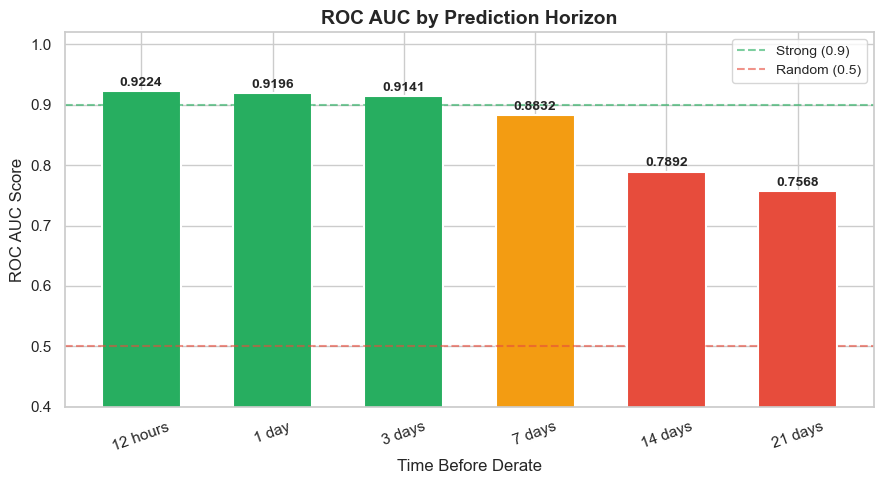

In [13]:
# ROC AUC by Horizon
auc_vals = results['ROC AUC'].values
bar_colors = ['#27ae60' if v >= 0.9 else '#f39c12' if v >= 0.8 else '#e74c3c' for v in auc_vals]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(results['Horizon'], auc_vals, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)
ax.axhline(0.9, color='#27ae60', linestyle='--', alpha=0.6, label='Strong (0.9)')
ax.axhline(0.5, color='#e74c3c', linestyle='--', alpha=0.6, label='Random (0.5)')
ax.set_ylim(0.4, 1.02)
ax.set_title('ROC AUC by Prediction Horizon', fontweight='bold', fontsize=14)
ax.set_xlabel('Time Before Derate')
ax.set_ylabel('ROC AUC Score')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, auc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

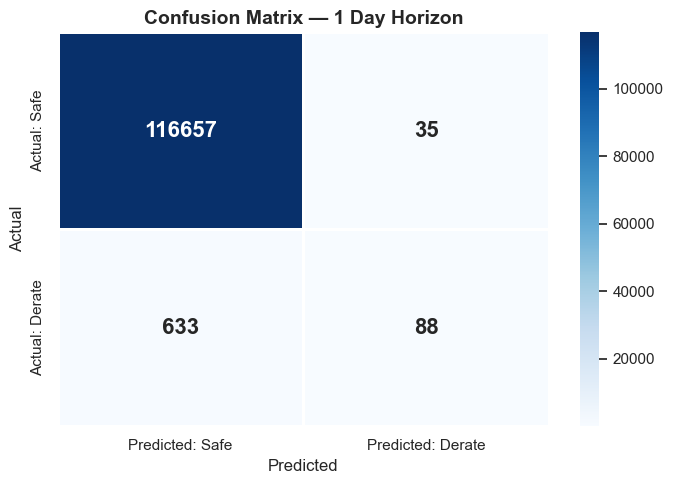

In [14]:
# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Safe', 'Predicted: Derate'],
            yticklabels=['Actual: Safe', 'Actual: Derate'],
            linewidths=2, linecolor='white', annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title('Confusion Matrix — 1 Day Horizon', fontweight='bold', fontsize=14)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

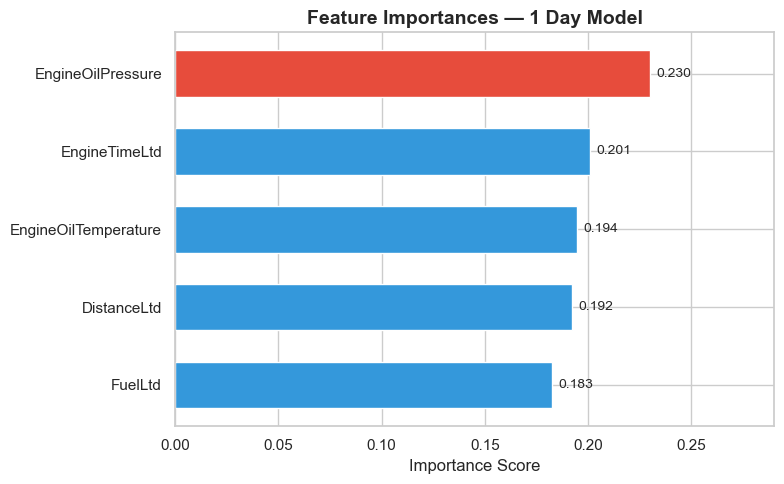

In [15]:
# Feature Importances
imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model_1d.feature_importances_
}).sort_values('Importance')

colors_imp = ['#3498db'] * len(imp_df)
colors_imp[-1] = '#e74c3c'

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors_imp, edgecolor='white', height=0.6)
ax.set_title('Feature Importances — 1 Day Model', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance Score')
for i, val in enumerate(imp_df['Importance']):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=10)
ax.set_xlim(0, imp_df['Importance'].max() + 0.06)
plt.tight_layout()
plt.show()

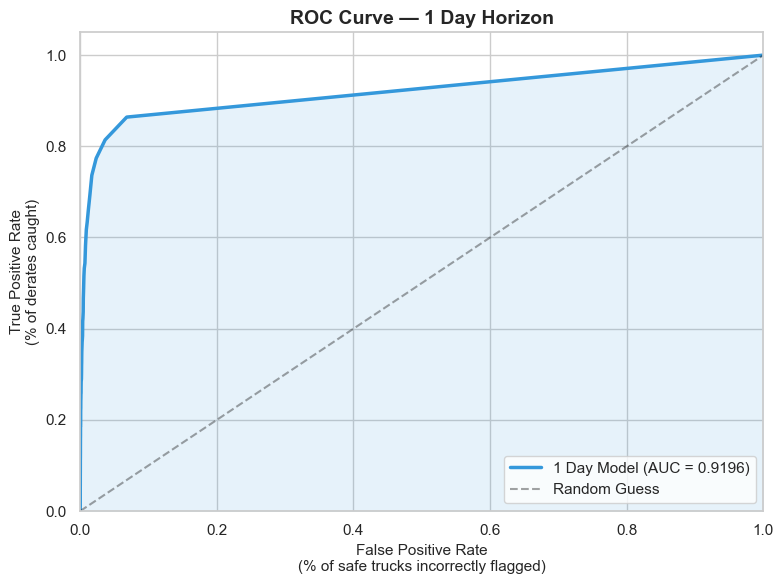

In [16]:
# ROC Curve — 1 Day Horizon
y_prob_1d = model_1d.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_1d, y_prob_1d)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#3498db', lw=2.5, label='1 Day Model (AUC = 0.9196)')
ax.fill_between(fpr, tpr, alpha=0.12, color='#3498db')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1.5, label='Random Guess')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate\n(% of safe trucks incorrectly flagged)', fontsize=11)
ax.set_ylabel('True Positive Rate\n(% of derates caught)', fontsize=11)
ax.set_title('ROC Curve — 1 Day Horizon', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()